In [1]:
import pygimli as pg 
import matplotlib.pyplot as plt
import numpy as np
from pygimli.physics import ert
import pygimli.meshtools as mt
from scipy.interpolate import griddata
import pandas as pd
import os 


22/03/26 - 13:16:03 - pyGIMLi - WARNING - Keyword argument changed from 'cmap' to 'cMap' and will be removed in v 
22/03/26 - 13:16:03 - pyGIMLi - INFO - Cache c:\Users\sider\.conda\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 53): C:\Users\sider\AppData\Roaming\pygimli\Cache\17970140561219481632


Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'k', 'm', 'n', 'valid']


22/03/26 - 13:16:04 - pyGIMLi - INFO - Data error estimate (min:max)  0.050002784420979926 : 0.05087045266628544
22/03/26 - 13:16:04 - pyGIMLi - INFO - 0.6560036253095495 4389.835910924968
22/03/26 - 13:16:04 - pyGIMLi - INFO - Simulated data:  Data: Sensors: 21 data: 171, nonzero entries: ['a', 'b', 'err', 'i', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']
22/03/26 - 13:16:04 - pyGIMLi - INFO - The data contains :  ['a', 'b', 'err', 'i', 'ip', 'iperr', 'k', 'm', 'n', 'r', 'rhoa', 'u', 'valid']
22/03/26 - 13:16:04 - pyGIMLi - INFO - Sim rhoa (min/max) :  143.518212584289 645.7771046176305
22/03/26 - 13:16:04 - pyGIMLi - INFO - Selected data noise % (min/ma)x :  5.000278442097993 5.087045266628544
22/03/26 - 13:16:04 - pyGIMLi - INFO - filtered rhoa minmax dd :  143.518212584289 645.7771046176305


relativeError set to a value > 0.5 .. assuming this is a percentage Error level dividing them by 100


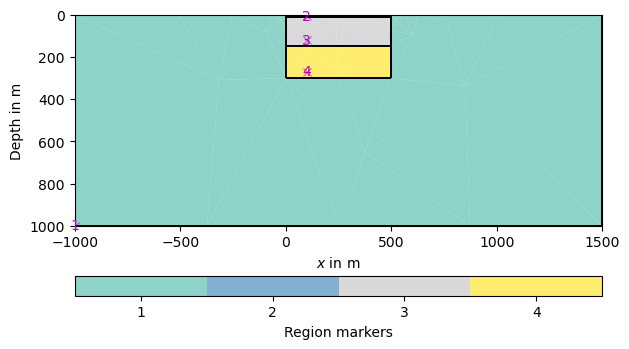

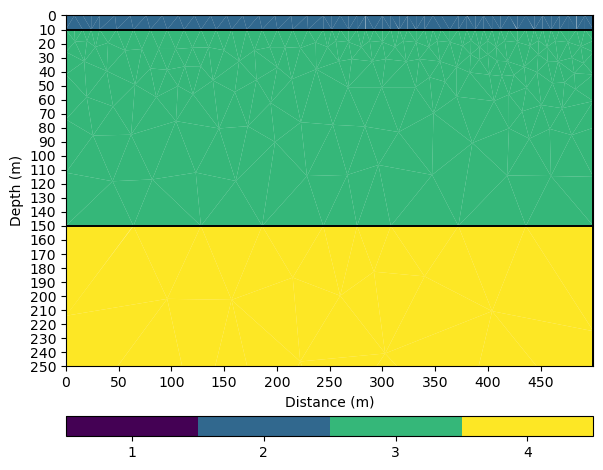

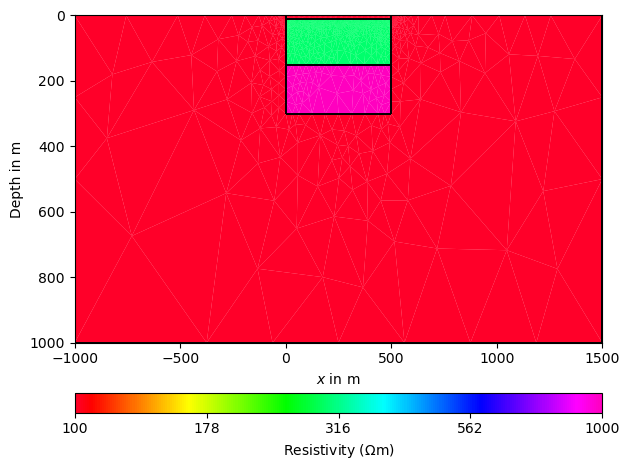

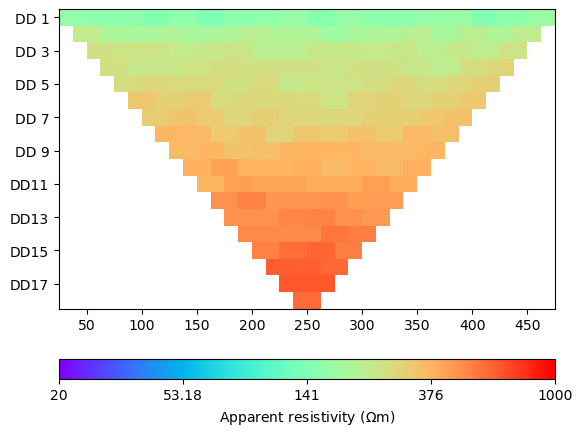

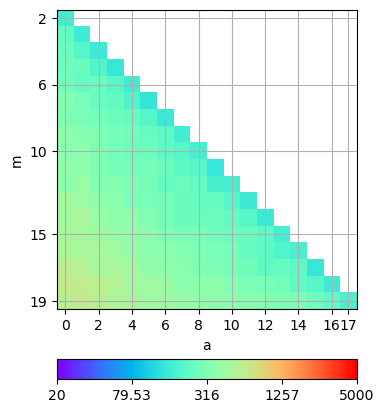

In [2]:
world=mt.createWorld(start=[-1000,0],end=[1500,-1000],worldMarker=1)

body1=mt.createRectangle(start=[0,0],end=[500,-10],marker=2)
body2=mt.createRectangle(start=[0,-10],end=[500,-150],marker=3)
body3=mt.createRectangle(start=[0,-150],end=[500,-300],marker=4)
geom=world+body1+body2+body3

pg.show(geom,showMesh=True,quality=34)

mesh_cut = mt.createMesh(geom, quality=34)

x_min,x_max= 0,500
y_min,y_max= -250,0

ax, cbar = pg.show(mesh_cut, data=mesh_cut.cellMarkers(), 
                   showMesh=False, aspect='auto', 
                   cmap=plt.get_cmap("viridis", 4), cbar=True)
cbar.mappable.set_clim(0.5, 4.5)
cbar.set_ticks([1, 2, 3, 4])

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_yticks(np.arange(y_min, 1, 10)) 
ax.set_xticks(np.arange(x_min, x_max, 50)) 
ax.set_xlabel("Distance (m)")   
ax.set_ylabel("Depth (m)")

plt.draw()

spacing=25
scheme=ert.createData(
    elecs=np.linspace(start=0,stop=500,num=len(np.arange(0,501,spacing)))
    , schemeName='dd'
)
print(scheme)
for p in scheme.sensors():
    geom.createNode(p)
    geom.createNode(p-[0,0.1]) # create 2  nodes for FTDT
mesh_fwr=mt.createMesh(geom,quality=34)
rhomap=[[1,100],
        [2,100],
        [3,300],
        [4,1000]]
pg.show(mesh_fwr,data=rhomap,label=pg.unit('res'), cMap='gist_rainbow',logScale=True,aspect='auto')


data=ert.simulate(mesh_fwr,scheme=scheme, res=rhomap, noiseLevel=5, noiseAbs=1e-6, seed=1337)

pg.info(np.linalg.norm(data['err']),np.linalg.norm(data['rhoa']))
pg.info('Simulated data: ',data)
pg.info('The data contains : ',data.dataMap().keys())
pg.info('Sim rhoa (min/max) : ' ,min(data['rhoa']), max(data['rhoa']))
pg.info('Selected data noise % (min/ma)x : ', min(data['err'])*100, max(data['err'])*100)

data.remove(data['rhoa']<0)
pg.info('filtered rhoa minmax dd : ', min(data['rhoa']), max(data['rhoa']))

output_dir = "simple_ore"
os.makedirs(output_dir, exist_ok=True) #Make new dir to save files

data.save(os.path.join(output_dir, f'{output_dir}_dd.dat'))

ert.show(data,cMap='rainbow',cMin=20,cMax=1000,logScale=True,title='DD')   #pseudosection
pg.viewer.mpl.showDataContainerAsMatrix(data,'a','m', 'rhoa',cMap='rainbow',cMin=20,cMax=5000,logScale=True,title='DD')

np.save(os.path.join(output_dir, f'{output_dir}_abmn_dd.npy'), np.column_stack([data['a'], data['b'], data['m'], data['n']]))
np.save(os.path.join(output_dir, f'{output_dir}_res_all_dd.npy'), np.column_stack([data['rhoa']]))
abmn_data_dd = np.load(os.path.join(output_dir, f'{output_dir}_abmn_dd.npy'))
res_data_dd=np.load(os.path.join(output_dir, f'{output_dir}_res_all_dd.npy'))

In [3]:
# Function to handle NaN values and get the NaN mask

def fill_nan(image):
    
    nan_mask = np.isnan(image)
    mean_value = np.nanmean(image)
    image[nan_mask] = mean_value

    return image, nan_mask


# Function to reconstruct the image using significant indices and their values

def reconstruct_compressed_image(image_shape, significant_indices, pixel_values):

    # Create an empty image with the given shape
    compressed_image = np.full(image_shape, np.nan)

    # Assign the provided pixel values to the significant indices
    compressed_image[significant_indices] = pixel_values

    # Interpolate to fill in the missing values
    x, y = np.meshgrid(np.arange(image_shape[1]), np.arange(image_shape[0]))
    mask = ~np.isnan(compressed_image)
    interpolated_image = griddata(
        (x[mask], y[mask]),  # Points with known values
        compressed_image[mask],  # Known values
        (x, y),  # Points to interpolate
        method='linear'  # Interpolation 
        )
    return interpolated_image


# Function to perform SVD and reconstruct image using significant pixels

def compress_and_reconstruct(image, num_singular_values,method='DD'):

    # Handle NaN values and get the NaN mask

    image, nan_mask = fill_nan(image)


    # Perform SVD
    U, S, Vt = np.linalg.svd(image, full_matrices=False)


    # Keep only the top 'num_singular_values' singular values

    U_reduced = U[:, :num_singular_values]
    S_reduced = np.diag(S[:num_singular_values])
    Vt_reduced = Vt[:num_singular_values, :]

    # Reconstruct the image using significant pixels
    compressed_image = np.dot(U_reduced, np.dot(S_reduced, Vt_reduced))

    # Identify significant pixel indices based on contributions
    contributions = np.abs(U_reduced) @ np.abs(Vt_reduced)

    rows,cols = np.arange(image.shape[0]),np.arange(image.shape[1])
 
    z=rows/np.max(rows)
    if method == 'SLM':
        z_factor = 0.6
    elif method == 'DD':
        # 0.4 for SLM, 0.2 for DD
        z_factor = 0.5
    else:
        print('error, choose method')

    depth_weight=1+z_factor*z   
    depth_weight=depth_weight[:,None] #2D IMPORTANT!!! 1D->WEIGHTING MORE TO DISTANT PIXELS  
    contributions*=depth_weight

    contributions[nan_mask] = -np.inf
    rows_0=np.where(~nan_mask[:,0])[0] #only non-nans for the fist column to force the linear interp   

    if len(rows_0)>0:
        r_min=rows_0[0]
        r_max=rows_0[-1]
        r_med=rows_0[len(rows_0)//2]
        contributions[r_min,0]=np.inf 
        contributions[r_max,0]=np.inf
        contributions[r_med,0]=np.inf   #force to include them

    flat_indices = np.argsort(contributions.flatten())[::-1][:num_singular_values]

    #flat_indices=np.r_[0,image.shape[0]*image.shape[1]-1,flat_indices]
    #Convert flat indices to 2D indices

    significant_indices = np.unravel_index(flat_indices, image.shape)

    #Restore NaN values in the original positions
    compressed_image[nan_mask] = np.nan
 
    return compressed_image, significant_indices,nan_mask


#Function to plot ERT measurements as a checkerboard heatmap

def plot_ert_checkerboard(data,plot=0):

    """
    Plots ERT measurements as a checkerboard heatmap.
    Parameters:
    data (pd.DataFrame): A DataFrame containing columns 'A', 'B', 'M', 'N', and 'Res'.
    """

    #Extract unique electrode positions
    electrodes = np.unique(data[['A', 'B', 'M', 'N']].values)
    electrode_map = {electrode: idx for idx, electrode in enumerate(sorted(electrodes))}

    #Create a grid

    grid_size = len(electrode_map)
    heatmap = np.full((grid_size, grid_size), np.nan)

    #Map values to the grid

    for _, row in data.iterrows():
        x = electrode_map[row['A']]
        y = electrode_map[row['M']]
        heatmap[y, x] = row['Res']


    if plot==1:

        #Plot the checkerboard heatmap
        plt.figure(figsize=(10, 8))

        plt.imshow(np.log10(heatmap), cmap='gist_rainbow', interpolation='nearest')

        plt.colorbar(label='ERT Measurement Value')

        plt.xticks(ticks=np.arange(grid_size), labels=sorted(electrode_map.keys()), rotation=90)

        plt.yticks(ticks=np.arange(grid_size), labels=sorted(electrode_map.keys()))

        plt.xlabel('Electrode A')

        plt.ylabel('Electrode N')

        plt.title('ERT Checkerboard Heatmap')

        plt.show()
    return heatmap

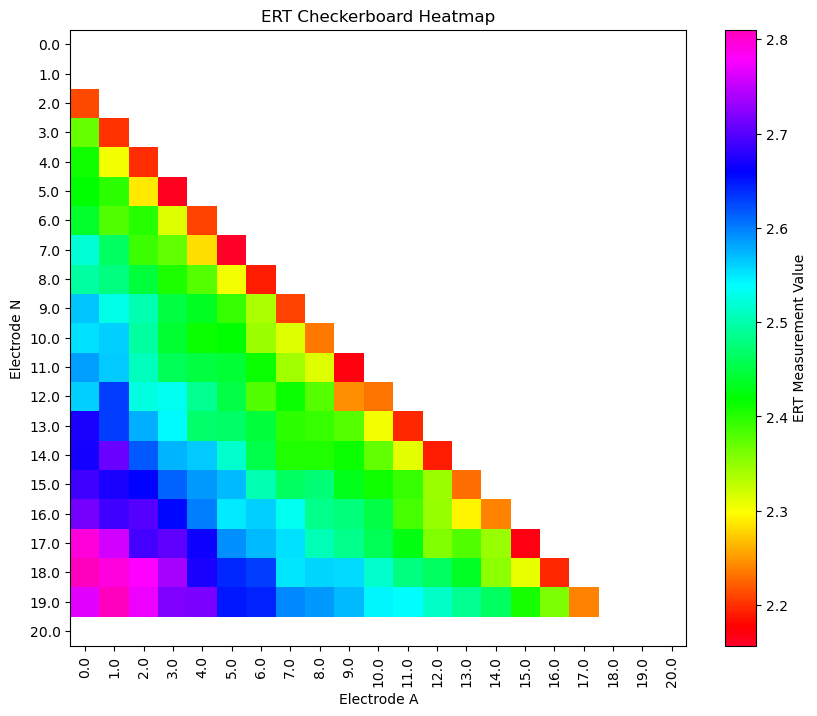

In [4]:
abmn=np.load(f'{output_dir}/{output_dir}_abmn_dd.npy')
#create the first dataframe for electrode mapping
res_all = np.load(f'{output_dir}/{output_dir}_res_all_dd.npy')
data_all = np.column_stack([abmn, res_all[:,0]])
data = pd.DataFrame(data_all, columns=['A','B','M','N','Res'])

electrodes = np.unique(data[['A', 'B', 'M', 'N']].values)
electrode_map = {electrode: idx for idx, electrode in enumerate(sorted(electrodes))}
image=plot_ert_checkerboard(data,plot=1) 

num_singular_values = 30
compressed_image, significant_indices,nan_mask=compress_and_reconstruct(image, num_singular_values)
image[nan_mask] = np.nan

#Get pixel values at significant indices
pixel_values = compressed_image[significant_indices]
real_values = image[significant_indices]

#Reconstruct the compressed image using significant indices and their values
reconstructed_compressed_image = reconstruct_compressed_image(image.shape, significant_indices, real_values)
predicted_values=reconstructed_compressed_image[significant_indices]





Significant pixel indices (2D): (array([ 2, 19, 11, 19, 18, 15, 18, 19, 17, 14, 18, 14, 19, 14, 16, 18, 17,
       19, 18, 18, 16, 16, 19, 13, 10, 15, 19, 13, 17, 19], dtype=int64), array([ 0,  0,  0, 17, 15, 13, 16,  1, 15,  8,  1,  7,  4, 12, 14, 12,  0,
       15,  6,  8,  5, 13,  8,  9,  8,  4,  5, 11,  2, 13], dtype=int64))
Pixel values at significant indices: [163.29050743 583.73862305 383.87224775 174.09650573 203.03041081
 169.28953438 157.57722511 645.34960414 147.38955399 253.51038951
 621.92206586 252.79933201 522.0215118  155.03568831 173.70408023
 290.79252596 625.35522059 255.33755038 426.8593369  361.04777901
 354.08733142 196.68960333 385.62298728 239.12109952 171.7383894
 385.35335733 445.67225466 157.27605531 491.28916132 307.70124302]
171
30


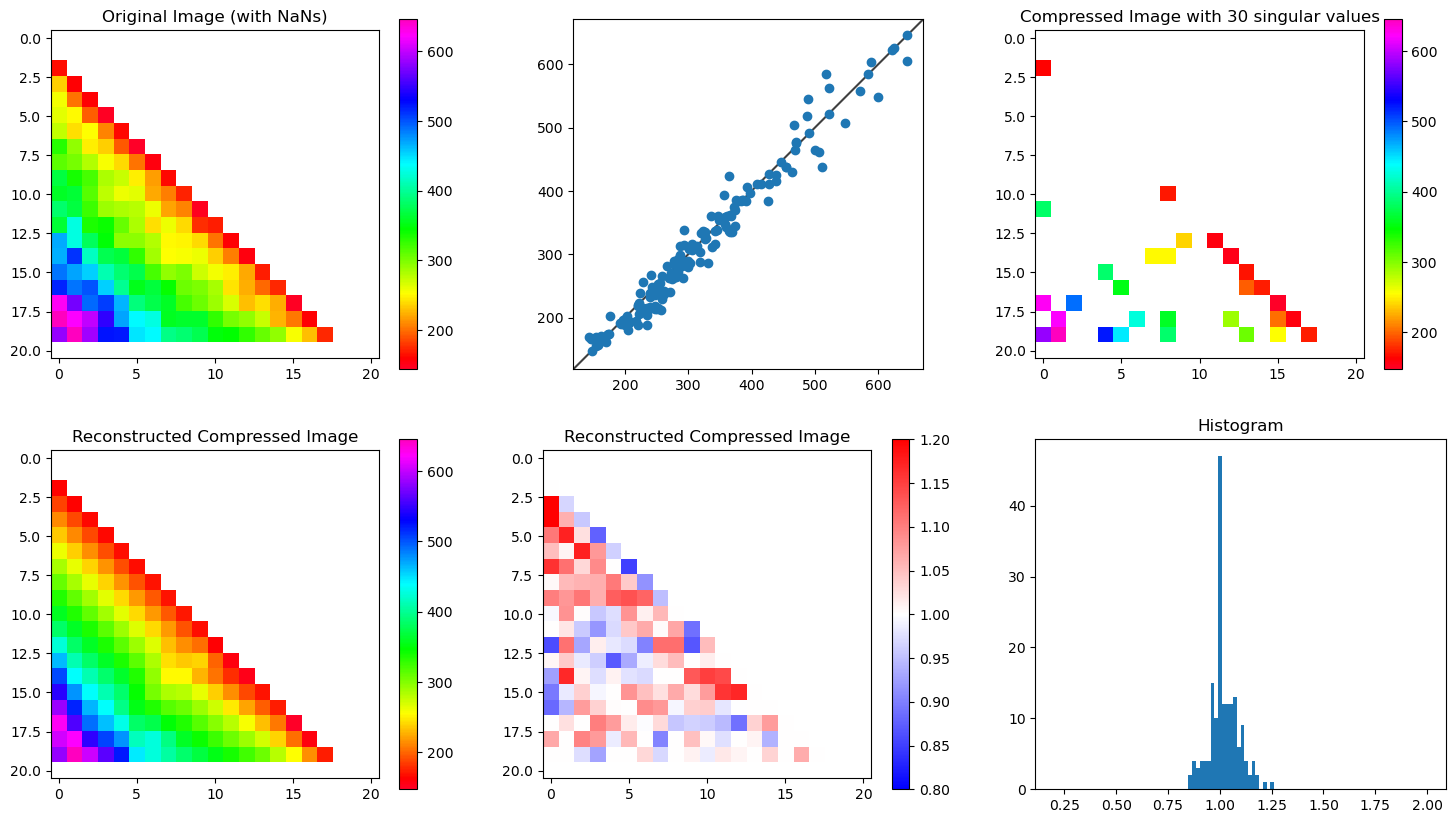

In [5]:
fig , ( (ax1,ax2,ax5) , (ax3,ax4,ax6)) = plt.subplots(2,3, figsize=(18,10))

#Plot 1: Original Image  
ax1.set_title("Original Image (with NaNs)")
im1=ax1.imshow(image, cmap='gist_rainbow')
plt.colorbar(im1)

#Plot 2: Scatter Plot
ax2.scatter(image.ravel(),reconstructed_compressed_image.ravel())

lims = [
np.min([ax2.get_xlim(), ax2.get_ylim()]),  # min of both axes
np.max([ax2.get_xlim(), ax2.get_ylim()]),  # max of both axes
]

ax2.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
ax2.set_aspect('equal')
ax2.set_xlim(lims)
ax2.set_ylim(lims)

#Plot 3: Reconstructed Image
ax3.set_title("Reconstructed Compressed Image")
reconstructed_compressed_image[nan_mask] = np.nan
im3=ax3.imshow(reconstructed_compressed_image, cmap='gist_rainbow')
plt.colorbar(im3)

#Plot 4: Ratio Image
ax4.set_title("Reconstructed Compressed Image")
im4=ax4.imshow(image/reconstructed_compressed_image, cmap='bwr',vmin=0.8,vmax=1.2)
plt.colorbar(im4)

#Plot 5: Compressed Image
del1=np.asarray(significant_indices)
to_plot_image=np.copy(image)
to_plot_image[:]=np.nan
to_plot_image[del1[0,:].T,del1[1,:].T]=predicted_values

ax5.set_title(f"Compressed Image with {num_singular_values} singular values")
compressed_image[nan_mask] = np.nan
im5=ax5.imshow(to_plot_image, cmap='gist_rainbow')
plt.colorbar(im5)

#Plot 6: Histogram
ax6.set_title("Histogram")
ax6.hist(image.ravel()/reconstructed_compressed_image.ravel(),bins=100,range=(0.2,2))
plt.savefig(f'{output_dir}/{output_dir}_dd_compression_plots.png')
print("Significant pixel indices (2D):", significant_indices)
print("Pixel values at significant indices:", pixel_values)
print(np.count_nonzero(np.isfinite(image.ravel())))
print(np.count_nonzero(np.isfinite(pixel_values)))

electrodes = np.unique(data[['A', 'B', 'M', 'N']].values)
electrode_map = {electrode: idx for idx, electrode in enumerate(sorted(electrodes))}

new_rhoa = []
for _, row in data.iterrows():
    x=electrode_map[row['A']]
    y=electrode_map[row['M']]
    
    
    val=reconstructed_compressed_image[y, x]
    new_rhoa.append(val)

new_rhoa=np.array(new_rhoa)
np.save(f'{output_dir}/{output_dir}_res_dd_reconstructed.npy', new_rhoa)
